# Задание 8. Логистическая регрессия: определение языка текста

Что нужно сделать:
- загрузить тексты двух книг (русская и английская) в виде строк, очистить от знаков препинания
  и выделить отдельные слова;
- нарезать тексты на фрагменты разной длины от 10 до 100 слов — это и будут обучающие примеры;
- посчитать для каждого фрагмента два признака: отношение количества слов к количеству букв
  и отношение количества уникальных слов к общему количеству слов;
- обучить логистическую регрессию, которая по фрагменту выдает вероятность того, что он на русском
  или на английском языке;
- посчитать метрики качества (Accuracy, Precision, Recall, F1);
- визуализировать признаковое пространство: цветом закрасить вероятность принадлежности к классу,
  сверху нанести точки-фрагменты.

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)

np.random.seed(42)

## Часть 1. Готовим данные из текстов книг

### Шаг 1. Загружаем тексты как строки

Русский текст — И. С. Тургенев, «Отцы и дети» (та же книга, что на графике из условия).
Английский — H. Melville, «Moby-Dick» (взять «Гроздья гнева» не получилось, книга не в свободном доступе,
а условие разрешает любые тексты).

In [2]:
text_ru = open("texts/ru_otcy_i_deti.txt", encoding="utf-8").read()
text_en = open("texts/en_moby_dick.txt", encoding="utf-8").read()

print("русский текст:", len(text_ru), "символов")
print("английский текст:", len(text_en), "символов")
print()
print(text_ru[:200])

русский текст: 355726 символов
английский текст: 1218940 символов

Отцы и дети

Роман

Книга: И. С. Тургенев. «Накануне. Отцы и дети»

Издательство «Художественная литература», Москва, 1979

— Что, Петр, не видать еще? — спрашивал 20-го мая 1859 года, выходя без шапк


### Шаг 2. Чистим текст от знаков препинания и выделяем слова

Приводим все к нижнему регистру и заменяем на пробел все, что не является буквой (знаки препинания, цифры,
переводы строк). После этого достаточно разбить строку по пробелам — получится список слов.

In [3]:
# оставляем только буквы (русские и латинские), остальное превращаем в пробелы
def to_words(text):
    text = text.lower()
    text = re.sub(r"[^a-zа-яё]+", " ", text)
    return text.split()

In [4]:
words_ru = to_words(text_ru)
words_en = to_words(text_en)

print("слов в русском тексте:", len(words_ru))
print("слов в английском тексте:", len(words_en))
print()
print(words_ru[:15])
print(words_en[:15])

слов в русском тексте: 54791
слов в английском тексте: 219054

['отцы', 'и', 'дети', 'роман', 'книга', 'и', 'с', 'тургенев', 'накануне', 'отцы', 'и', 'дети', 'издательство', 'художественная', 'литература']
['moby', 'dick', 'or', 'the', 'whale', 'by', 'herman', 'melville', 'contents', 'etymology', 'extracts', 'supplied', 'by', 'a', 'sub']


Английская книга почти в 4 раза длиннее русской, поэтому английских фрагментов получилось бы в 4 раза больше
и классы вышли бы несбалансированными. Обрезаем английский текст до того же количества слов.

In [5]:
words_en = words_en[:len(words_ru)]

print("после обрезки:", len(words_ru), "и", len(words_en), "слов")

после обрезки: 54791 и 54791 слов


### Шаг 3. Режем тексты на фрагменты разной длины (от 10 до 100 слов)

Идем по списку слов подряд и каждый раз откусываем случайное число слов от 10 до 100. Фрагменты получаются
разной длины, как и требует условие, и не пересекаются между собой.

In [6]:
def split_to_fragments(words):
    fragments = []
    i = 0
    while i + 100 <= len(words):
        n = np.random.randint(10, 101)   # длина очередного фрагмента
        fragments.append(words[i:i + n])
        i += n
    return fragments

In [7]:
fragments_ru = split_to_fragments(words_ru)
fragments_en = split_to_fragments(words_en)

print("фрагментов: русских", len(fragments_ru), " английских", len(fragments_en))
print("средняя длина фрагмента:", round(np.mean([len(f) for f in fragments_ru]), 1), "слов")
print()
print(" ".join(fragments_ru[3]))

фрагментов: русских 1022  английских 1016
средняя длина фрагмента: 53.5 слов

генерал года полуграмотный грубый но не злой русский человек всю жизнь свою тянул лямку командовал сперва бригадой потом дивизией и постоянно жил в провинции где в силу своего чина играл довольно значительную роль николай петрович родился на юге россии подобно старшему своему брату павлу о котором речь впереди и воспитывался до четырнадцатилетнего возраста дома окруженный дешевыми гувернерами развязными но подобострастными адъютантами и прочими полковыми и штабными личностями родительница его из


### Шаг 4. Считаем два признака для каждого фрагмента

- признак 1 — количество слов / количество букв во фрагменте (буквы считаем как суммарную длину всех слов);
- признак 2 — количество уникальных слов / общее количество слов.

Класс 0 — русский, класс 1 — английский.

In [8]:
def fragment_features(fragment):
    word_count = len(fragment)
    char_count = sum(len(w) for w in fragment)     # всего букв во фрагменте
    uniq_count = len(set(fragment))
    return word_count / char_count, uniq_count / word_count

In [9]:
rows = []

for f in fragments_ru:
    x1, x2 = fragment_features(f)
    rows.append([x1, x2, len(f), 0])

for f in fragments_en:
    x1, x2 = fragment_features(f)
    rows.append([x1, x2, len(f), 1])

df = pd.DataFrame(rows, columns=["words_per_char", "uniq_per_word", "length", "lang"])
df.head()

,words_per_char,uniq_per_word,length,lang
0,0.191223,0.819672,61,0
1,0.147239,0.833333,24,0
2,0.188811,0.790123,81,0
3,0.162413,0.928571,70,0
4,0.164835,0.933333,30,0


In [10]:
# средние значения признаков по языкам
df.groupby("lang")[["words_per_char", "uniq_per_word"]].agg(["mean", "std", "min", "max"]).round(3)

words_per_char                      uniq_per_word                 
               mean    std    min    max          mean    std  min  max
lang                                                                   
0             0.199  0.022  0.123  0.302         0.880  0.074  0.6  1.0
1             0.234  0.025  0.153  0.333         0.822  0.090  0.5  1.0

У русских фрагментов отношение слов к буквам в среднем 0.199, у английских — 0.234, то есть русские слова
действительно длиннее. По второму признаку разница меньше (0.880 против 0.822), и разброс большой, так что
основную работу по разделению будет делать первый признак.

### Шаг 5. Смотрим, как признаки зависят от длины фрагмента

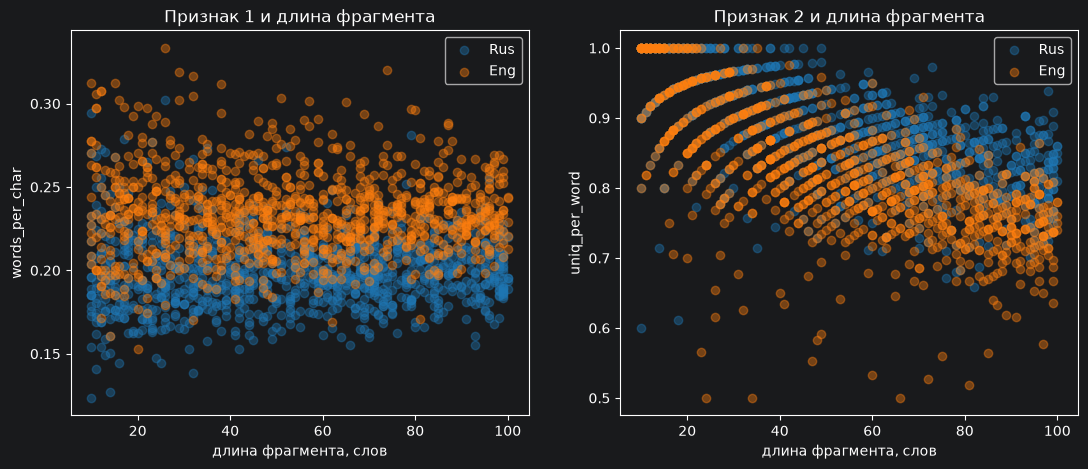

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for lang, name, color in [(0, "Rus", "tab:blue"), (1, "Eng", "tab:orange")]:
    sub = df[df["lang"] == lang]
    axes[0].scatter(sub["length"], sub["words_per_char"], color=color, alpha=0.4, label=name)
    axes[1].scatter(sub["length"], sub["uniq_per_word"], color=color, alpha=0.4, label=name)

axes[0].set_xlabel("длина фрагмента, слов")
axes[0].set_ylabel("words_per_char")
axes[0].set_title("Признак 1 и длина фрагмента")
axes[0].legend()

axes[1].set_xlabel("длина фрагмента, слов")
axes[1].set_ylabel("uniq_per_word")
axes[1].set_title("Признак 2 и длина фрагмента")
axes[1].legend()

plt.show()

Первый признак от длины фрагмента почти не зависит — только разброс у коротких фрагментов больше.
А второй признак с ростом длины падает: в коротком фрагменте почти все слова разные (значение около 1),
а в длинном начинают повторяться предлоги и союзы. Поэтому по вертикали точки обоих классов сильно
размазаны и перемешаны.

## Часть 2. Обучаем логистическую регрессию

### Шаг 6. Делим выборку на обучающую и тестовую

In [12]:
X = df[["words_per_char", "uniq_per_word"]].values
y = df["lang"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("обучающая:", X_train.shape, " тестовая:", X_test.shape)

обучающая: (1426, 2)  тестовая: (612, 2)


### Шаг 7. Масштабируем признаки

Оба признака — небольшие дроби (0.2 и 0.85), а логистическая регрессия по умолчанию с регуляризацией,
поэтому на таких маленьких значениях она недоучивается. Приводим признаки к нулевому среднему и единичному
разбросу: $x_{norm} = (x - mean)/std$. Среднее и std считаем **только по обучающей выборке**.

In [13]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_n = (X_train - X_mean) / X_std
X_test_n = (X_test - X_mean) / X_std

### Шаг 8. Обучаем модель

In [14]:
model = LogisticRegression()
model.fit(X_train_n, y_train)

print("коэффициенты:", model.coef_.round(3))
print("свободный член:", model.intercept_.round(3))

коэффициенты: [[ 2.032 -0.331]]
свободный член: [0.064]


Коэффициент у первого признака положительный и большой (2.03), у второго — маленький и отрицательный (-0.33).
То есть чем больше отношение слов к буквам, тем вероятнее английский, а второй признак только чуть-чуть
подправляет ответ.

### Шаг 9. Метрики качества на тестовой выборке

In [15]:
y_pred = model.predict(X_test_n)

print("Accuracy  =", round(accuracy_score(y_test, y_pred), 3))
print("Precision =", round(precision_score(y_test, y_pred), 3))
print("Recall    =", round(recall_score(y_test, y_pred), 3))
print("F1        =", round(f1_score(y_test, y_pred), 3))

Accuracy  = 0.815
Precision = 0.822
Recall    = 0.803
F1        = 0.813


In [16]:
# матрица ошибок: по строкам правильные языки, по столбцам предсказанные
cm = confusion_matrix(y_test, y_pred)
pd.DataFrame(cm, index=["Rus", "Eng"], columns=["Rus (прогноз)", "Eng (прогноз)"])

,Rus (прогноз),Eng (прогноз)
Rus,254,53
Eng,60,245


Accuracy около 0.82, остальные метрики примерно такие же, ошибки распределены почти симметрично между
классами. Всего два простых признака, поэтому идеального разделения и не ожидалось: у Мелвилла много длинных
слов, и часть его фрагментов по длине слов попадает в "русскую" область.

### Шаг 10. Пробуем модель на новых фрагментах

In [17]:
# модель принимает фрагмент текста и выдает вероятности языков
def predict_language(text):
    words = to_words(text)
    x1, x2 = fragment_features(words)
    x = (np.array([[x1, x2]]) - X_mean) / X_std
    p = model.predict_proba(x)[0]
    return p

In [18]:
frag1 = "Базаров медленно двинулся вперед, и Павел Петрович пошел к нему, заложив левую руку в карман"
frag2 = "It is not down in any map; true places never are. Call me Ishmael and I will tell you the whole story"

for frag in [frag1, frag2]:
    p = predict_language(frag)
    print(frag[:50], "...")
    print("  Rus =", round(p[0], 3), " Eng =", round(p[1], 3))

Базаров медленно двинулся вперед, и Павел Петрович ...
  Rus = 0.862  Eng = 0.138
It is not down in any map; true places never are.  ...
  Rus = 0.019  Eng = 0.981


## Часть 3. Визуализация признакового пространства

Покрываем плоскость двух признаков сеткой точек, для каждой точки сетки спрашиваем у модели вероятность
английского языка и заливаем ее цветом. Сверху наносим сами фрагменты, раскрашенные по настоящему языку.

In [19]:
xx, yy = np.meshgrid(np.linspace(0.10, 0.40, 300),
                     np.linspace(0.50, 1.00, 300))

grid = np.c_[xx.ravel(), yy.ravel()]
grid_n = (grid - X_mean) / X_std                     # сетку масштабируем так же, как обучающие данные
zz = model.predict_proba(grid_n)[:, 1]               # вероятность класса "Eng"
zz = zz.reshape(xx.shape)

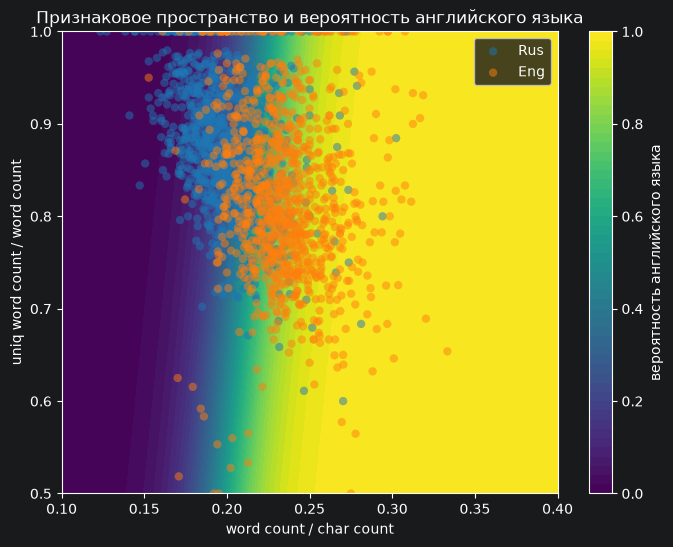

In [20]:
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, zz, levels=50, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(ticks=np.linspace(0, 1, 6), label="вероятность английского языка")

for lang, name, color in [(0, "Rus", "tab:blue"), (1, "Eng", "tab:orange")]:
    sub = df[df["lang"] == lang]
    plt.scatter(sub["words_per_char"], sub["uniq_per_word"],
                color=color, alpha=0.5, edgecolors="none", label=name)

plt.xlabel("word count / char count")
plt.ylabel("uniq word count / word count")
plt.title("Признаковое пространство и вероятность английского языка")
plt.legend()
plt.show()

Темная область слева — модель уверена, что текст русский, желтая справа — что английский, узкая полоса
посередине (около 0.21) — это граница, где вероятности близки к 0.5. Граница почти вертикальная: она
определяется в основном первым признаком, а по второму признаку наклонена совсем слегка.

## Выводы

Логистическая регрессия на двух простых признаках отличает русский текст от английского с accuracy около 0.82.
Работает это потому, что русские слова в среднем длиннее английских (падежные и родовые окончания), поэтому
на одно и то же количество букв в русском тексте приходится меньше слов — отношение слов к буквам у русских
фрагментов заметно ниже. Второй признак (доля уникальных слов) сам по себе язык почти не различает: он больше
зависит от длины фрагмента — у коротких фрагментов слова почти не повторяются и значение близко к 1, у длинных
оно падает, — поэтому точки обоих классов размазаны по вертикали, и граница классификации получается почти
вертикальной.